In [1]:
cd ../

c:\Users\eduar\Documents\usp\AMST\ml_timeseries_usp


In [2]:
import os
from src.data.make_dataset import DatasetCreator
from src.data.make_hierarchical_dataset import DatasetHierarchicalAggregator
from src.data.refine_dataset import HierarchicalTimeSeriesOutlierRemover
from src.data.split import HierarchicalTrainTestSplit
from src.features.build_features import FeaturesBuilder
from src.config import load_config
from src.models.tuning import ModelTuning
from src.models.train_model import CreateCanditateModel
from src.evaluation.backtest_evaluation import ModelEvaluate,CompareRecMethods
from src.data.back_to_origin import DatasetReconciliator
import warnings
warnings.filterwarnings("ignore")
config = load_config()

if config['cache']:

    print('loading data...')
    ## == LOAD AGGREGATED DATASETS AND OBJECTS 
    Hagg = DatasetHierarchicalAggregator(config)
    
    Y_df = Hagg.load_processed(filename='dataset.parquet')
    S_df = Hagg.load_processed(filename='structure.parquet')
    tags = Hagg.load_tags(filename='tags.joblib')
    Y_exogen_cat_df = Hagg.load_processed(filename='exog_cat_vars.parquet')
    Y_exogen_num_df = Hagg.load_processed(filename='exog_num_vars.parquet')
    future_df = Hagg.load_processed(filename='future.parquet')

    pass

else:
    ## == CREATE DATASET
    df = DatasetCreator(config).run()

    ## == HIERARCHICAL AGGREGATION
    Y_df, S_df, tags, Y_exogen_cat_df, Y_exogen_num_df, future_df = DatasetHierarchicalAggregator(config,df=df).run()

## == HIERARCHICAL TRAIN TEST SPLIT
split_dates = config['split_dates']
train , test = HierarchicalTrainTestSplit(Y_df, S_df, tags, Y_exogen_cat_df, Y_exogen_num_df,split_dates,config).run()

2025-12-09 21:56:01,432 - INFO - Config carregado de c:\Users\eduar\Documents\usp\AMST\ml_timeseries_usp\config.yaml
2025-12-09 21:56:02,043 - INFO - Config carregado de c:\Users\eduar\Documents\usp\AMST\ml_timeseries_usp\config.yaml


loading data...
DEBUG: Iniciando carregamento de data/processed/global\dataset.parquet
DEBUG: Dataset Carregado.
DEBUG: Iniciando carregamento de data/processed/global\structure.parquet
DEBUG: Dataset Carregado.
DEBUG: Carregando tags de tags.joblib
DEBUG: Iniciando carregamento de data/processed/global\exog_cat_vars.parquet
DEBUG: Dataset Carregado.
DEBUG: Iniciando carregamento de data/processed/global\exog_num_vars.parquet
DEBUG: Dataset Carregado.
DEBUG: Iniciando carregamento de data/processed/global\future.parquet
DEBUG: Dataset Carregado.
Train: 2022-01-01 → 2025-01-01 (37 meses)
Test (backtest): 2025-02-01 → 2025-07-01 (6 meses)


In [3]:
models = config['models']
cv_config = config['modeling']['cv_config']
methods = config['reconciliation']['methods']
min_trace_methods = config['reconciliation']['min_trace_methods']
mid_level = config['reconciliation']['middle_level']
train_metrics_path = config['paths']['metrics']['train_path']
evaluation_metrics_path = config['paths']['metrics']['evaluation_path']
time_col = config['time_col']
id_col = config['id_col']
target_col = config['target_col']

candidate_info = {}
candidate_performances = {}

model = 'LightGBM'

train_to_model = train.copy()
test_to_model = test.copy()


type_model = models[model]['type']
training_metric = config['modeling']['training_metric']
validation_metric = config['modeling']['validation_metric']
train_compare_metrics = config['modeling']['train_compare_metrics']
test_compare_metrics = config['modeling']['test_compare_metrics']
model_name = models[model]['name']

In [5]:
#Get Tuning info
fixed_params = models[model]['fixed_params']
param_space = config['parameter_space'][model]
mlforecast_params = config['modeling']['mlforecast']
static_features = mlforecast_params['fit_params']['static_features']

In [6]:
from mlforecast import MLForecast
from utilsforecast.losses import smape,mape,mase
import shap
import pandas as pd
import numpy as np
import optuna
from mlforecast.optimization import mlforecast_objective
from lightgbm import LGBMRegressor
from mlforecast.target_transforms import LocalBoxCox,Differences,LocalStandardScaler,LocalMinMaxScaler
from mlforecast.lag_transforms import RollingMean, ExpandingMean
def config_fn(trial):
    candidate_lags = [
        [1],
        [13],
        [1, 13],
        range(1, 33),
    ]
    lag_idx = trial.suggest_categorical('lag_idx', range(len(candidate_lags)))
    candidate_lag_tfms = [
        {
            1: [RollingMean(window_size=13)]
        },
        {
            1: [RollingMean(window_size=13)],
            13: [RollingMean(window_size=13)],
        },
        {
            13: [RollingMean(window_size=13)],
        },
        {
            4: [ExpandingMean(), RollingMean(window_size=4)],
            8: [ExpandingMean(), RollingMean(window_size=4)],
        }
    ]
    lag_tfms_idx = trial.suggest_categorical('lag_tfms_idx', range(len(candidate_lag_tfms)))
    candidate_targ_tfms = [
        [Differences([1])],
        [LocalBoxCox()],
        [LocalStandardScaler()],        
        [LocalBoxCox(), Differences([1])],
        [LocalBoxCox(), LocalStandardScaler()],
        [LocalBoxCox(), Differences([1]), LocalStandardScaler()],
    ]
    targ_tfms_idx = trial.suggest_categorical('targ_tfms_idx', range(len(candidate_targ_tfms)))
    return {
        'model_params': {
            'learning_rate': trial.suggest_float('learning_rate',0.01,0.1), 
            'objective': 'regression',
            'bagging_freq': 1,
            'num_threads': 2,
            'verbose': -1,
            'force_col_wise': True,
            'n_estimators': trial.suggest_int('n_estimators', 10, 1000, log=True),            
            'num_leaves': trial.suggest_int('num_leaves', 31, 1024, log=True),
            'lambda_l1': trial.suggest_float('lambda_l1', 0.01, 10, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 0.01, 10, log=True),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.75, 1.0),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.75, 1.0),
        },
        'mlf_init_params': {
            'lags': candidate_lags[lag_idx],
            'lag_transforms': candidate_lag_tfms[lag_tfms_idx],
            'target_transforms': candidate_targ_tfms[targ_tfms_idx],
            'date_features': ['month', 'quarter']
        },
        'mlf_fit_params': {
            'static_features': static_features
        }
    }

def loss(df, train_df):
    return mase(df, models=['model'],train_df=train,seasonality=config['seasonality'])['model'].mean()

In [7]:
optuna.logging.set_verbosity(optuna.logging.INFO)
objective = mlforecast_objective(
    df=train,
    config_fn=config_fn,
    loss=loss,    
    model=LGBMRegressor(),
    freq='MS',
    n_windows=1,
    h=1,
)
study = optuna.create_study(
    direction='minimize', sampler=optuna.samplers.TPESampler(seed=1)
)

[I 2025-12-09 21:56:15,492] A new study created in memory with name: no-name-7807d969-4ee6-46ce-9ccb-e37fb831085b


In [8]:
study.optimize(objective, n_trials=80)
best_value = study.best_value
best_trial_cfg = study.best_trial.user_attrs['config']
best_model_params = best_trial_cfg['model_params']
best_mlforecast_params = best_trial_cfg['mlf_init_params']
mlf_fit_params = best_trial_cfg['mlf_fit_params']
static_features = mlforecast_params['fit_params']['static_features']

[I 2025-12-09 21:56:22,921] Trial 0 finished with value: 11526704.776631895 and parameters: {'lag_idx': 1, 'lag_tfms_idx': 3, 'targ_tfms_idx': 5, 'learning_rate': 0.012464883387813356, 'n_estimators': 216, 'num_leaves': 132, 'lambda_l1': 0.47431786810463206, 'lambda_l2': 0.02637307779092461, 'bagging_fraction': 0.7995253722712197, 'feature_fraction': 0.9501861421688842}. Best is trial 0 with value: 11526704.776631895.
[I 2025-12-09 21:56:35,400] Trial 1 finished with value: 8.879790378310066 and parameters: {'lag_idx': 0, 'lag_tfms_idx': 0, 'targ_tfms_idx': 3, 'learning_rate': 0.03839640679054567, 'n_estimators': 232, 'num_leaves': 573, 'lambda_l1': 0.011346576147006612, 'lambda_l2': 1.7800530470464975, 'bagging_fraction': 0.9972152722266237, 'feature_fraction': 0.9370414135949598}. Best is trial 1 with value: 8.879790378310066.
[I 2025-12-09 21:56:35,977] Trial 2 finished with value: 2.122606318809677 and parameters: {'lag_idx': 1, 'lag_tfms_idx': 0, 'targ_tfms_idx': 1, 'learning_rate

In [67]:
best_model_params

{'learning_rate': 0.07391965556357367,
 'objective': 'regression',
 'bagging_freq': 1,
 'num_threads': 2,
 'verbose': -1,
 'force_col_wise': True,
 'n_estimators': 23,
 'num_leaves': 239,
 'lambda_l1': 3.914039930729276,
 'lambda_l2': 0.14810932329232987,
 'bagging_fraction': 0.9298269195559123,
 'feature_fraction': 0.9295494005489191}

In [69]:
mlf_fit_params

{'static_features': ['unique_id']}

In [9]:
final_model = MLForecast(
    models=[LGBMRegressor(**best_model_params)],
    freq='MS',
    **best_mlforecast_params,
)

In [10]:
final_model.fit(train,static_features=static_features,fitted=True)

MLForecast(models=[LGBMRegressor], freq=MS, lag_features=['lag1', 'lag13', 'rolling_mean_lag1_window_size13'], date_features=['month', 'quarter'], num_threads=1)

In [11]:
X_df = pd.read_parquet('data/processed/global/features/test/test_features.parquet')

In [12]:
prediction = final_model.predict(h=6,X_df=X_df)
df_preds = prediction.merge(test,on=['unique_id','ds'])

In [13]:
print(smape(df_preds,models='LGBMRegressor')[0].mean(),
      mape(df_preds,models='LGBMRegressor')[0].mean())

0.1778470514991434 0.37392156645691454


<Axes: >

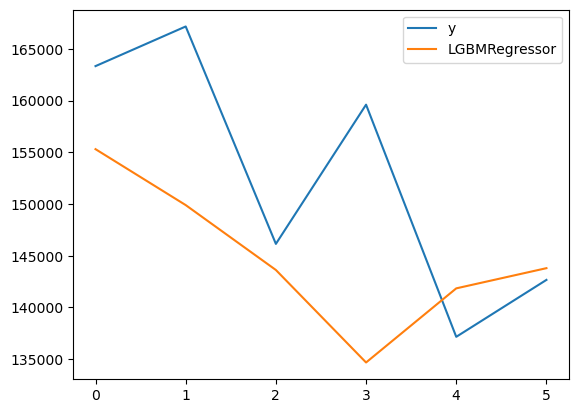

In [14]:
df_preds[df_preds['unique_id']=='total'][['y','LGBMRegressor']].plot()

In [15]:
best_value

0.578659517397286

In [24]:
import shap

In [26]:
from sklearn.preprocessing import LabelEncoder

In [16]:
cat_cols = ['marca', 'material', 'construcao', 'padronagem', 'decote', 'detalhe', 'regiao_loja', 'uf_loja', 'clima_loja', 'perfil_loja', 'porte_loja', 'sku', 'tamanho', 'cidade_loja', 'bairro_loja', 'cor']
X = final_model.preprocess(train,static_features=cat_cols).drop(columns=['ds','y'])

In [17]:
# Assuming final_model.models_['LGBMRegressor'] is your trained LightGBM model
explainer = shap.TreeExplainer(final_model.models_['LGBMRegressor'])
shap_values = explainer(X)  # Or explainer.shap_values(X) if needed for certain outputs

In [18]:
import matplotlib.pyplot as plt

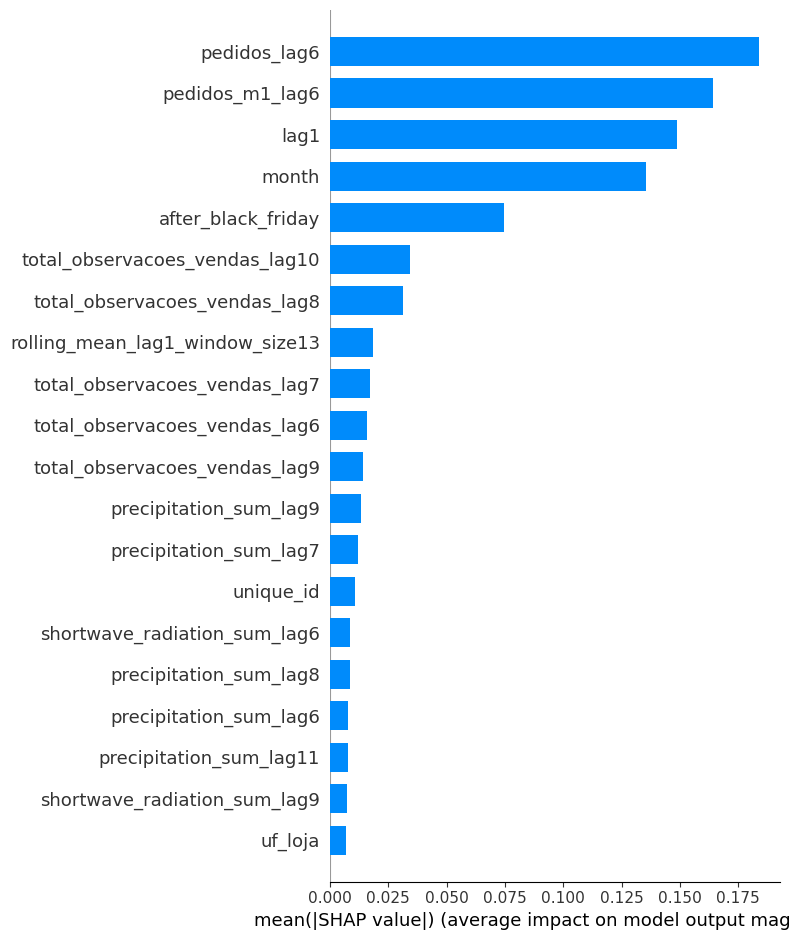

In [19]:
shap.summary_plot(shap_values, X, plot_type="bar")  # Versão em barras para importância global
plt.show()  # Ou plt.savefig('importancia_global.png') para salvar como imagem

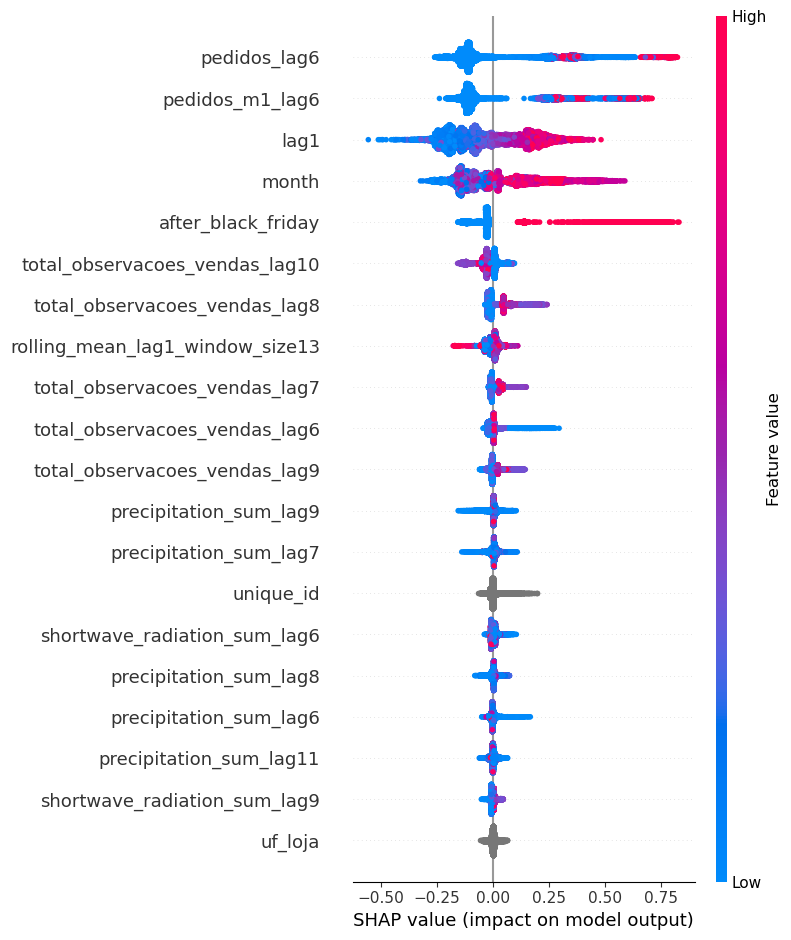

In [20]:
shap.summary_plot(shap_values, X)  # Beeswarm por default
plt.show()

In [21]:
train.groupby(['ds']).agg({'y':'sum','pedidos_lag6':'sum'}).corr()

,y,pedidos_lag6
y,1.000000,0.790066
pedidos_lag6,0.790066,1.000000


In [22]:
# Assuming shap.initjs() is already called for Jupyter
shap.force_plot(explainer.expected_value, shap_values[0].values, X.iloc[0])

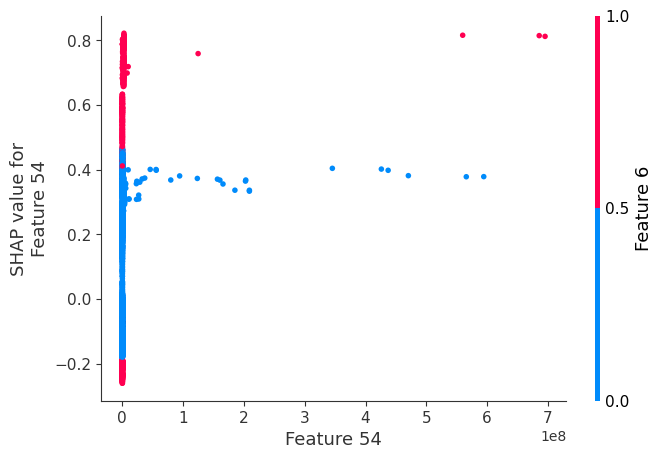

In [23]:
feature_names = list(X.columns)
uf_loja_index = feature_names.index('pedidos_lag6')

# Use shap_values.values (the NumPy array)
shap.dependence_plot(uf_loja_index, shap_values.values, X.values)
plt.show()

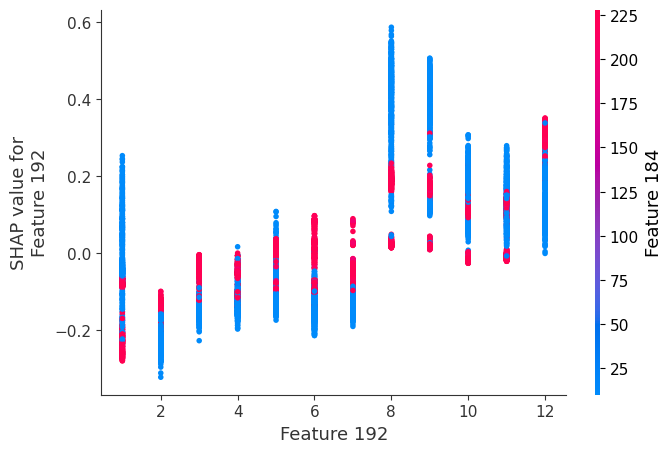

In [60]:
feature_names = list(X.columns)
month = feature_names.index('month')

# Use shap_values.values (the NumPy array)
shap.dependence_plot(month, shap_values.values, X.values)
plt.show()

In [65]:
#create model with best tuning parameters
candidate, fitted_values, metric,results_metrics = CreateCanditateModel(
                    df=train_to_model,
                    config=config,
                    cv_config=cv_config,
                    type_model=type_model,
                    model_name=model_name,
                    metric=best_value,
                    cv_metric = training_metric,
                    compare_metrics=train_compare_metrics,
                    model_params = best_model_params,
                    mlf_params = best_mlforecast_params,
                    mlf_fit_params = mlf_fit_params
                    ).run()
        
candidate_info.update({metric:candidate})
candidate_performances.update({model:results_metrics})
#eavluate model
prediction,validation_metric,results_metrics = ModelEvaluate(
                        candidate_model=final_model,
                        model_name=model_name,
                        fitted_values=fitted_values,
                        type_model=type_model,
                        train=train_to_model,
                        test=test_to_model,
                        validation_metric=validation_metric,
                        compare_metrics=test_compare_metrics,
                        config=config
                        ).run()

#Hierarchical Reconcilier
df_post_processed,recmethods = DatasetReconciliator(
                Y_df = Y_df,
                S_df = S_df,
                tags = tags,
                model_name = model_name,
                methods = methods,
                mid_level = mid_level,
                min_trace_methods = min_trace_methods,
                fitted_values = fitted_values,
                prediction = prediction
            ).run()

CompareRecMethods(
                        model_name=model_name,
                        df_post_processed=df_post_processed,      # seu df com as colunas reconciliadas (com "/")
                        fitted_values=fitted_values,       # só unique_id, ds, y do treino
                        test=test_to_model[[id_col,time_col,target_col]],                  # unique_id, ds, y do período de teste
                        config=config
                    ).run()

                            
for method in recmethods:
    
    df_rec_method = df_post_processed[[id_col,time_col,method]]

    # Evaluate with each hierarchical reconcilier
    prediction,validation_metric,results_metrics = ModelEvaluate(
                                                        candidate_model=None,
                                                        model_name=method,
                                                        fitted_values=fitted_values,
                                                        type_model=type_model,
                                                        train=train_to_model,
                                                        test=test_to_model,
                                                        validation_metric=validation_metric,
                                                        compare_metrics=test_compare_metrics,
                                                        config=config,
                                                        prediction=df_rec_method
                                                        ).run()


Calculando erro por série usando métrica principal: mase ...

=== Séries selecionadas para plot de CV ===
Hierarquia 'root' → 1 séries → todas em best_cases
Hierarquia 'total' → 2 séries → todas em best_cases
Hierarquia 'total/blusa' → 3 séries → todas em best_cases
Hierarquia 'total/blusa/cd1' → 84 séries → 5 melhores + 5 piores
Hierarquia 'total/blusa/cd2' → 233 séries → 5 melhores + 5 piores
Hierarquia 'total/blusa/cd3' → 9 séries → todas em best_cases
Hierarquia 'total/calca' → 3 séries → todas em best_cases
Hierarquia 'total/calca/cd1' → 81 séries → 5 melhores + 5 piores
Hierarquia 'total/calca/cd2' → 172 séries → 5 melhores + 5 piores
Hierarquia 'total/calca/cd3' → 8 séries → todas em best_cases

Total de plots gerados:
→ best_cases:  46 séries
→ worst_cases: 20 séries
Organização: cross_validation → [hierarquia] → best_cases / worst_cases (só quando >10)


Calculando erro por série no backtest usando métrica: smape ...

=== Plotando séries selecionadas no backtest (máx 10 por h